In [1]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline


/opt/anaconda3/envs/nlp_course_env/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn(


In [2]:
data=pd.read_csv("book_reviews_sample.csv")

In [3]:
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [5]:
data['reviewText'][0]

'Clean and funny. A bit busy with all the different plots going on. But overall a good read. Bye now.'

In [6]:
data["review_text_clean"]=data['reviewText'].str.lower()

In [11]:
data["review_text_clean"]=data.apply(lambda x:re.sub(r"([^\w\s])","",x["review_text_clean"]),axis=1)

In [12]:
data.head()

,index,reviewText,rating,review_text_clean
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...


In [13]:
vader_sentiment=SentimentIntensityAnalyzer()

In [18]:
data["vader_sentiment_score"]=data["review_text_clean"].apply(lambda review:vader_sentiment.polarity_scores(review)["compound"])

In [20]:
data.head()

,index,reviewText,rating,review_text_clean,vader_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767


In [26]:
bins=[-1,-0.1,0.1,1]
names=["negative","neutral","positive"]

In [27]:
data["vader_sentiment_lable"]=pd.cut(data["vader_sentiment_score"],bins,labels=names)

In [28]:
data.head()

,index,reviewText,rating,review_text_clean,vader_sentiment_score,vader_sentiment_labl,vader_sentiment_lable
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.7684,positive,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.9325,positive,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.6740,positive,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.6652,positive,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.4767,negative,negative


<Axes: xlabel='vader_sentiment_lable'>

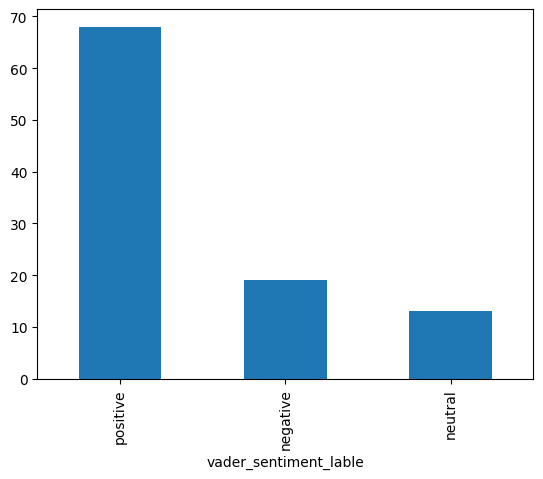

In [29]:
data["vader_sentiment_lable"].value_counts().plot.bar()

In [30]:
transformer_pipeline=pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


In [31]:
transformer_label=[]

In [36]:
for review in data["review_text_clean"].values:
    sentiment_list=transformer_pipeline(review)
    sentiment_label=[sent["label"] for sent in sentiment_list]
    transformer_label.append(sentiment_label)

data["transformer_sentiment_label"]=transformer_label

<Axes: xlabel='transformer_sentiment_label'>

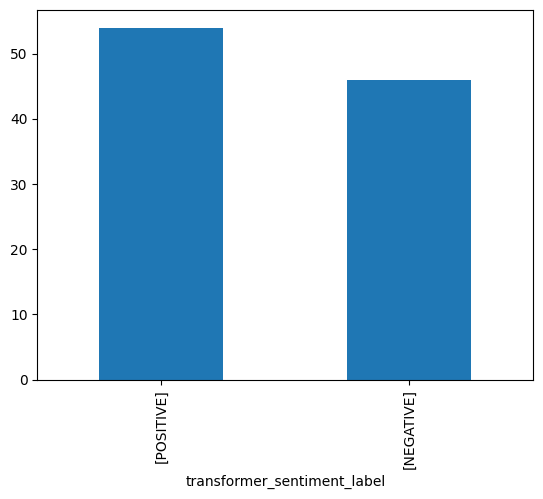

In [38]:
data["transformer_sentiment_label"].value_counts().plot.bar()